# Creating a model from RFlag flags
January 2, 2025

In this notebook, we will train a model off of the RFlag masks from a measurement set.

In [2]:
import sys
sys.path.append('../')

Here, we will use phase calibrator 3C147, which is a P-Band dataset.

In [3]:
from samrfi import RadioRFI

dir_path = '/home/gpuhost002/ddeal/RFI-AI/'

original_calib = '/home/gpuhost002/ddeal/RFI-AI/original_calib/calib_phase_tfcrop.ms'

datarfi_original = RadioRFI(vis=original_calib, dir_path=dir_path)
datarfi_original.load(mode='DATA', ant_i=2) # using first two antennas


Loading data...


100%|██████████| 2/2 [01:26<00:00, 43.00s/it]


(51, 4, 2048, 196)


In [4]:
import numpy as np

reflected_part = np.flip(datarfi_original.rfi_antenna_data, axis=-1)  # Alternatively, use arr[..., ::-1]
# Step 2: Concatenate along the last axis
new_arr = np.concatenate((datarfi_original.rfi_antenna_data, reflected_part), axis=-1)
datarfi_original.rfi_antenna_data = new_arr

Next, we load in the RFlag flags from our measurement set.

In [5]:
datarfi_original.load(ant_i=2, mode='FLAG')


Loading data...


  0%|          | 0/2 [00:00<?, ?it/s]

100%|██████████| 2/2 [00:53<00:00, 26.50s/it]


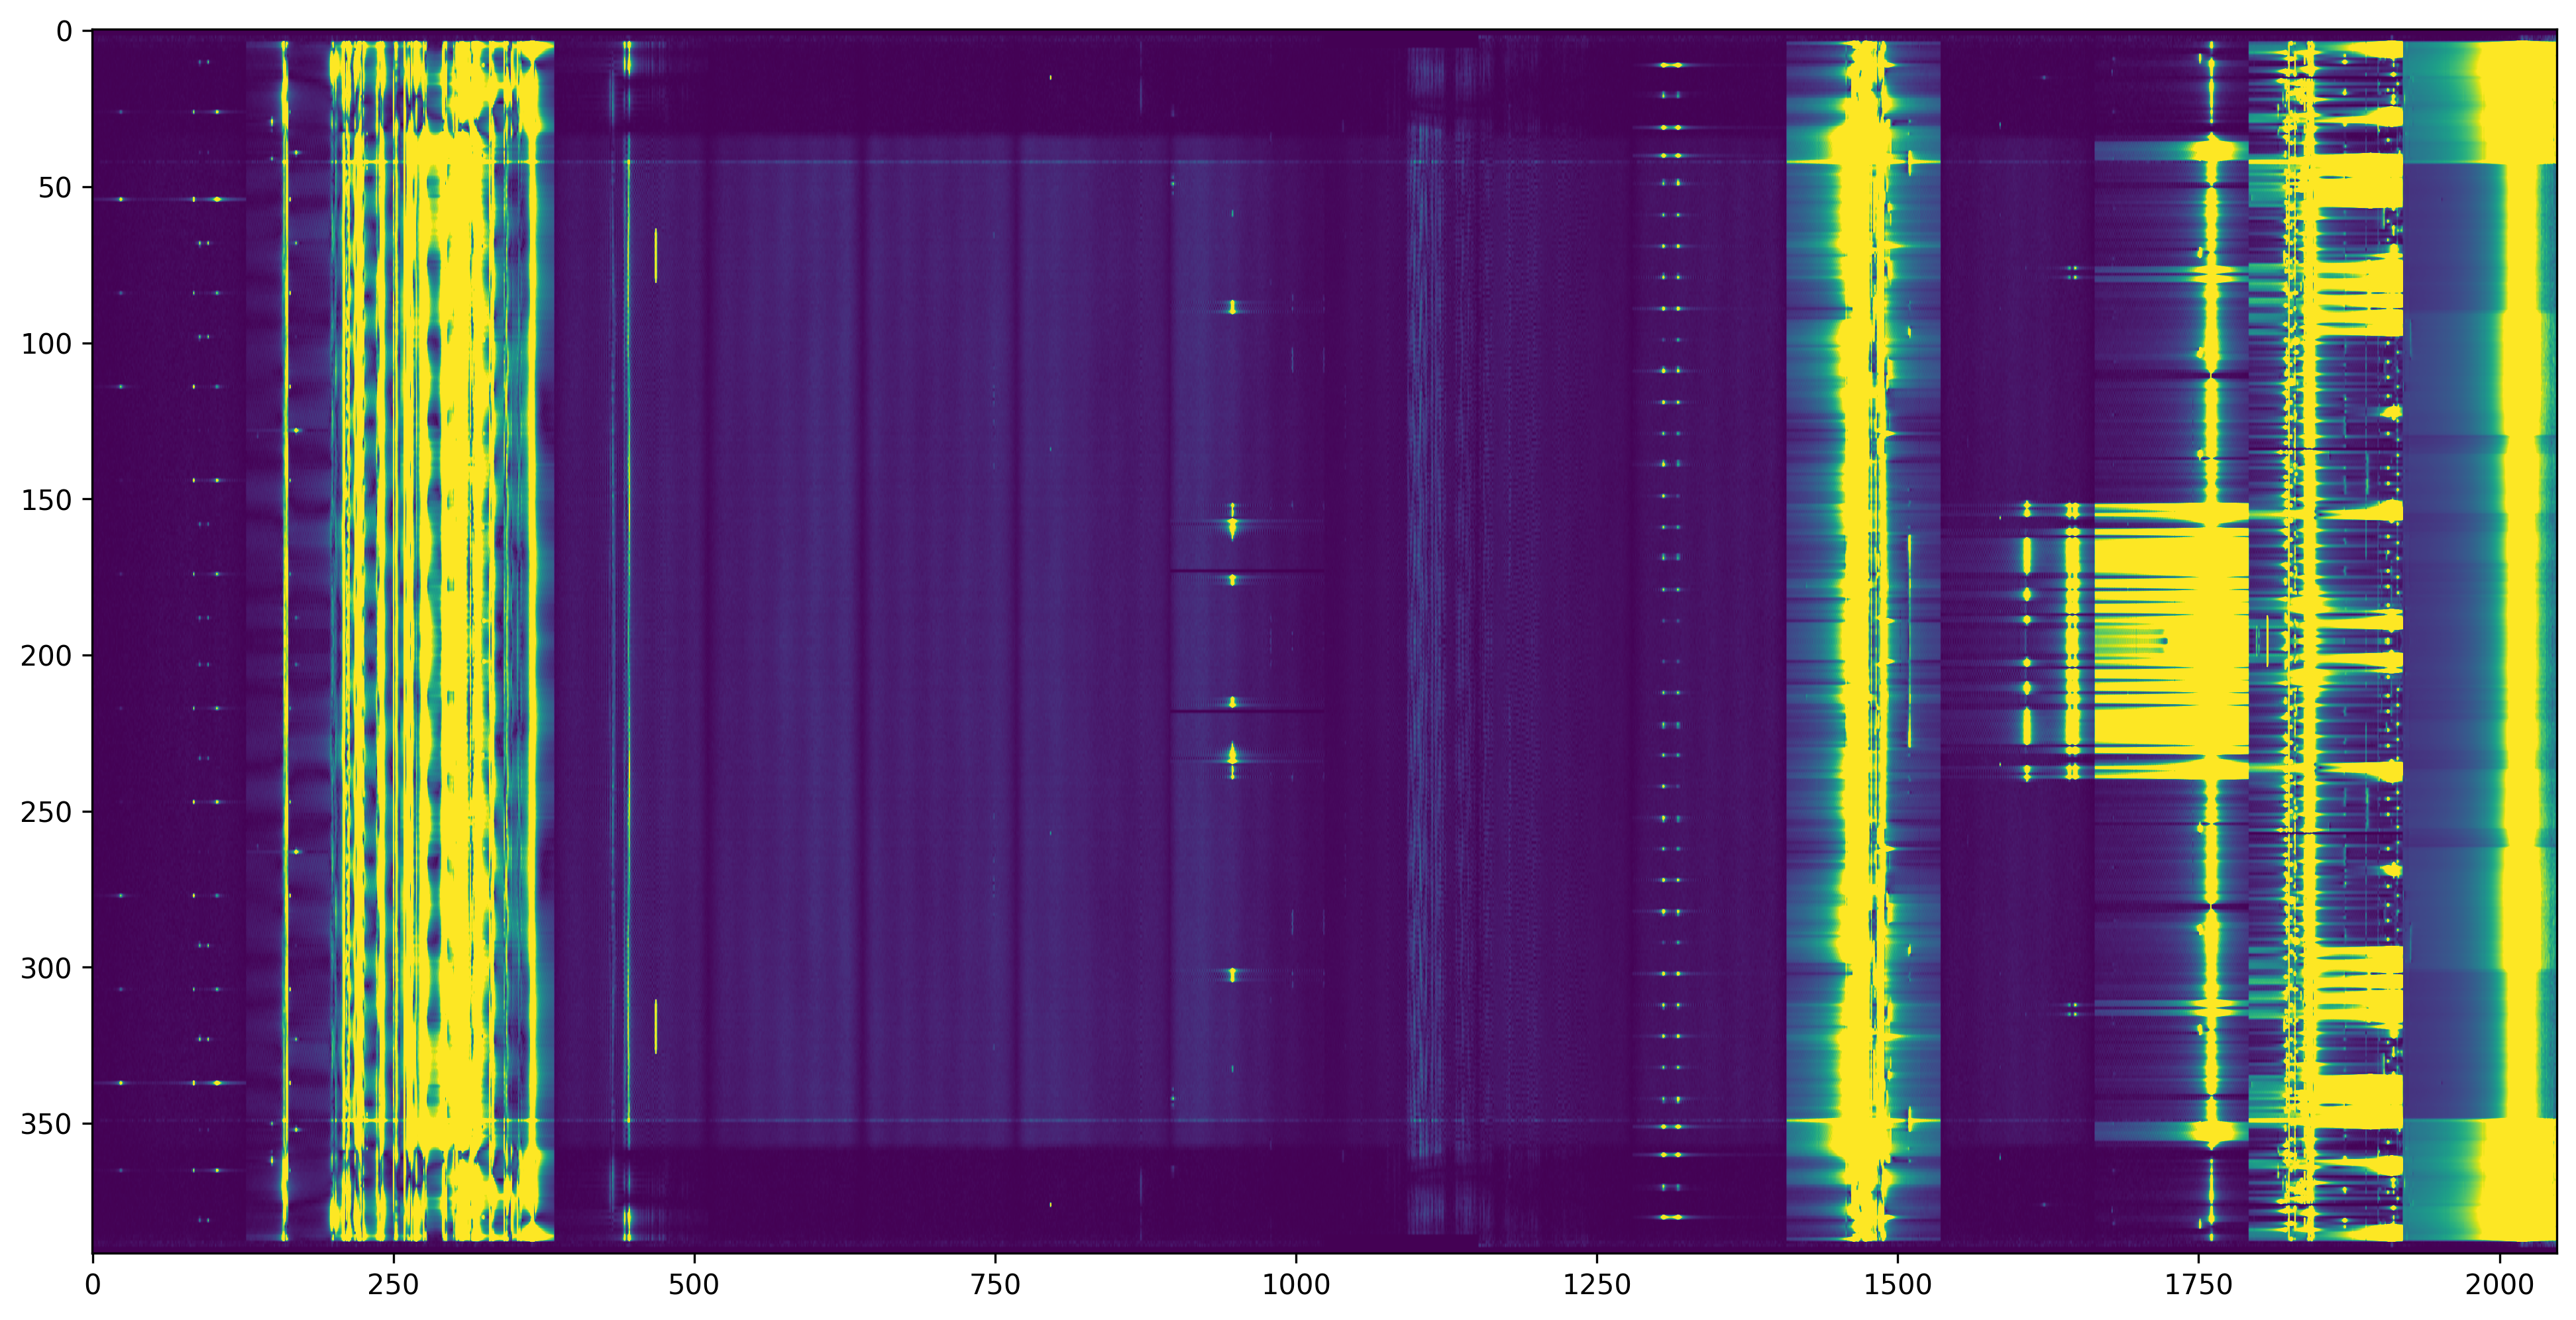

In [11]:
datarfi_original.plotter.plot(mode='DATA', baseline=1, polarization=0)

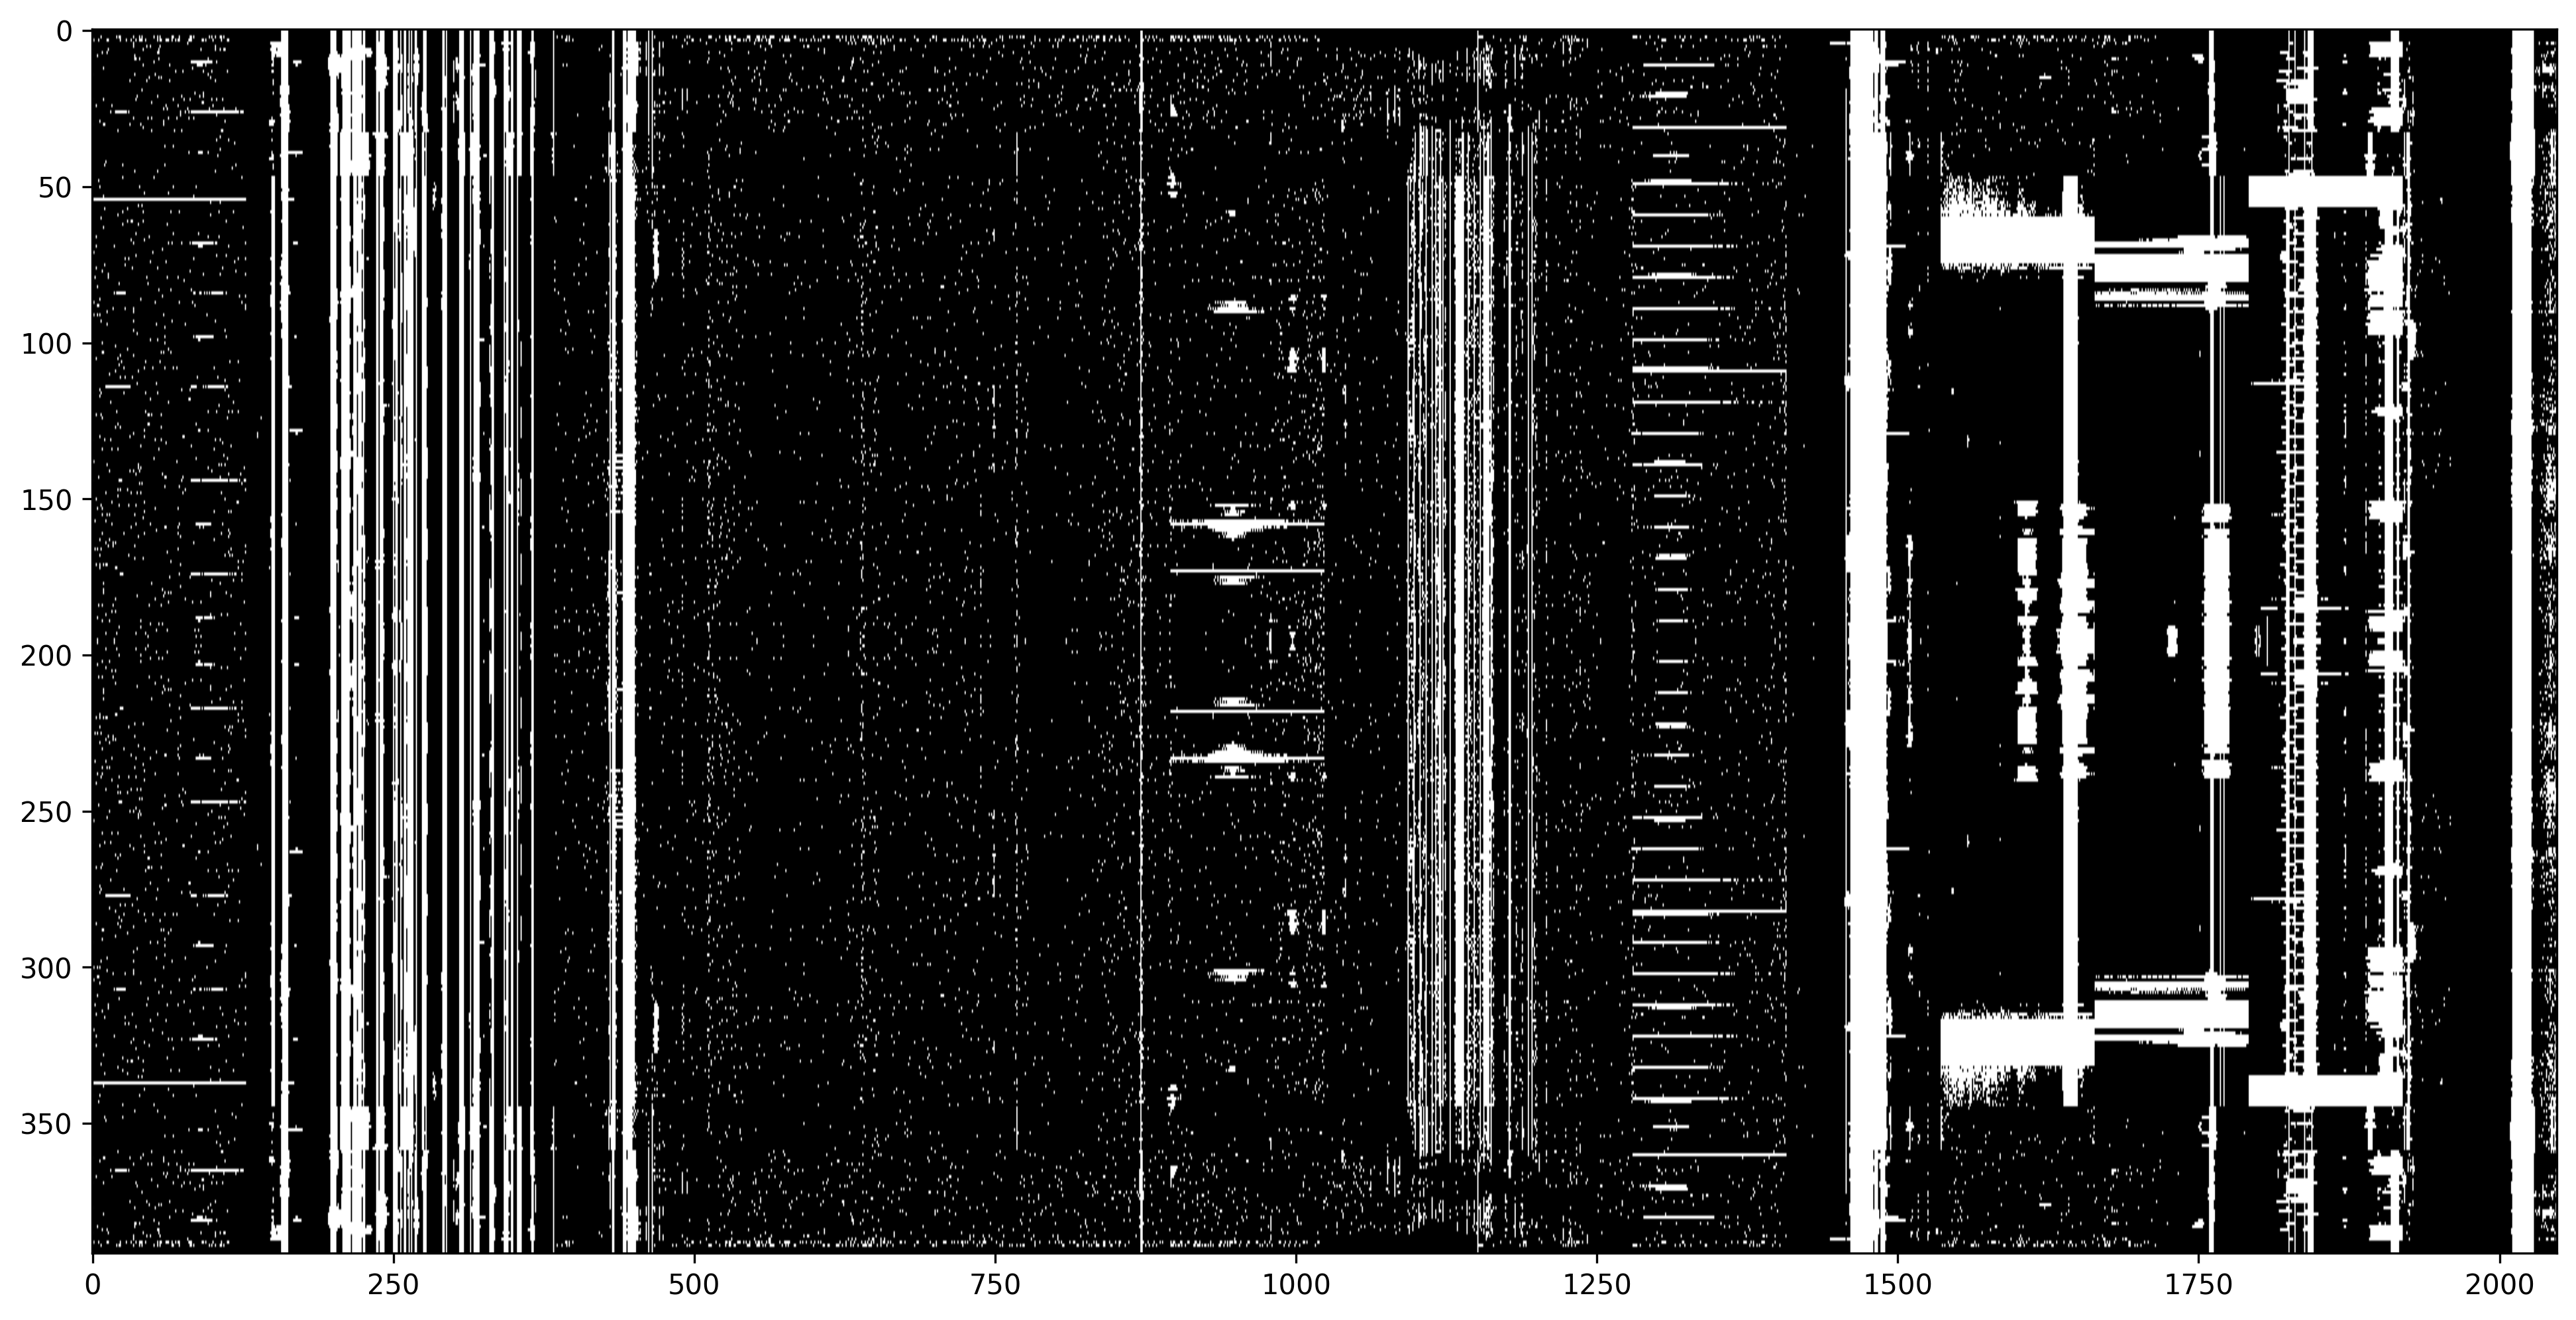

In [10]:
datarfi_original.flags = np.abs(datarfi_original.ms_flags)

reflected_part = np.flip(datarfi_original.flags, axis=-1)  # Alternatively, use arr[..., ::-1]
# Step 2: Concatenate along the last axis
new_arr = np.concatenate((datarfi_original.flags, reflected_part), axis=-1)
datarfi_original.flags = new_arr

datarfi_original.plotter.plot(mode='FLAG', baseline=1, polarization=0)

In [65]:
from samrfi import RFIDataset

rfi_dataset = RFIDataset(datarfi_original)
rfi_dataset.create_dataset(num_patches=600, patch_size=256, apply_stretching=False, custom_flag=True)


Applying median normalization only to 6528 patches...


100%|██████████| 6528/6528 [00:09<00:00, 683.09it/s]



Applying median normalization only to 6528 patches...


100%|██████████| 6528/6528 [00:08<00:00, 786.09it/s]


(6528, 256, 256) (6528, 256, 256)


In [66]:
rfi_dataset.dataset.shape

(600, 2)

In [67]:
import matplotlib.pyplot as plt

In [12]:
img_num = np.random.randint(0, 600-1)

example_image = rfi_dataset.dataset[img_num]["image"]
example_mask = rfi_dataset.dataset[img_num]["label"]

fig, axes = plt.subplots(1, 2, figsize=(10, 5), dpi=300)

# Plot the first image on the left
axes[0].imshow(np.array(example_image).T[0],)  # Assuming the first image is grayscale
axes[0].set_title("Image")

# Plot the second image on the right
axes[1].imshow(np.array(example_mask).T,)  # Assuming the second image is grayscale
axes[1].set_title("Mask")

# Hide axis ticks and labels
for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xticklabels([])
    ax.set_yticklabels([])

# Display the images side by side
plt.show()

NameError: name 'rfi_dataset' is not defined

In [72]:
rfi_dataset.save_dataset()

Saving the dataset (0/1 shards):   0%|          | 0/600 [00:00<?, ? examples/s]


Training model...


100%|██████████| 150/150 [06:41<00:00,  2.67s/it]


EPOCH: 0
Mean loss: 1.2842213809490204


<Figure size 640x480 with 0 Axes>

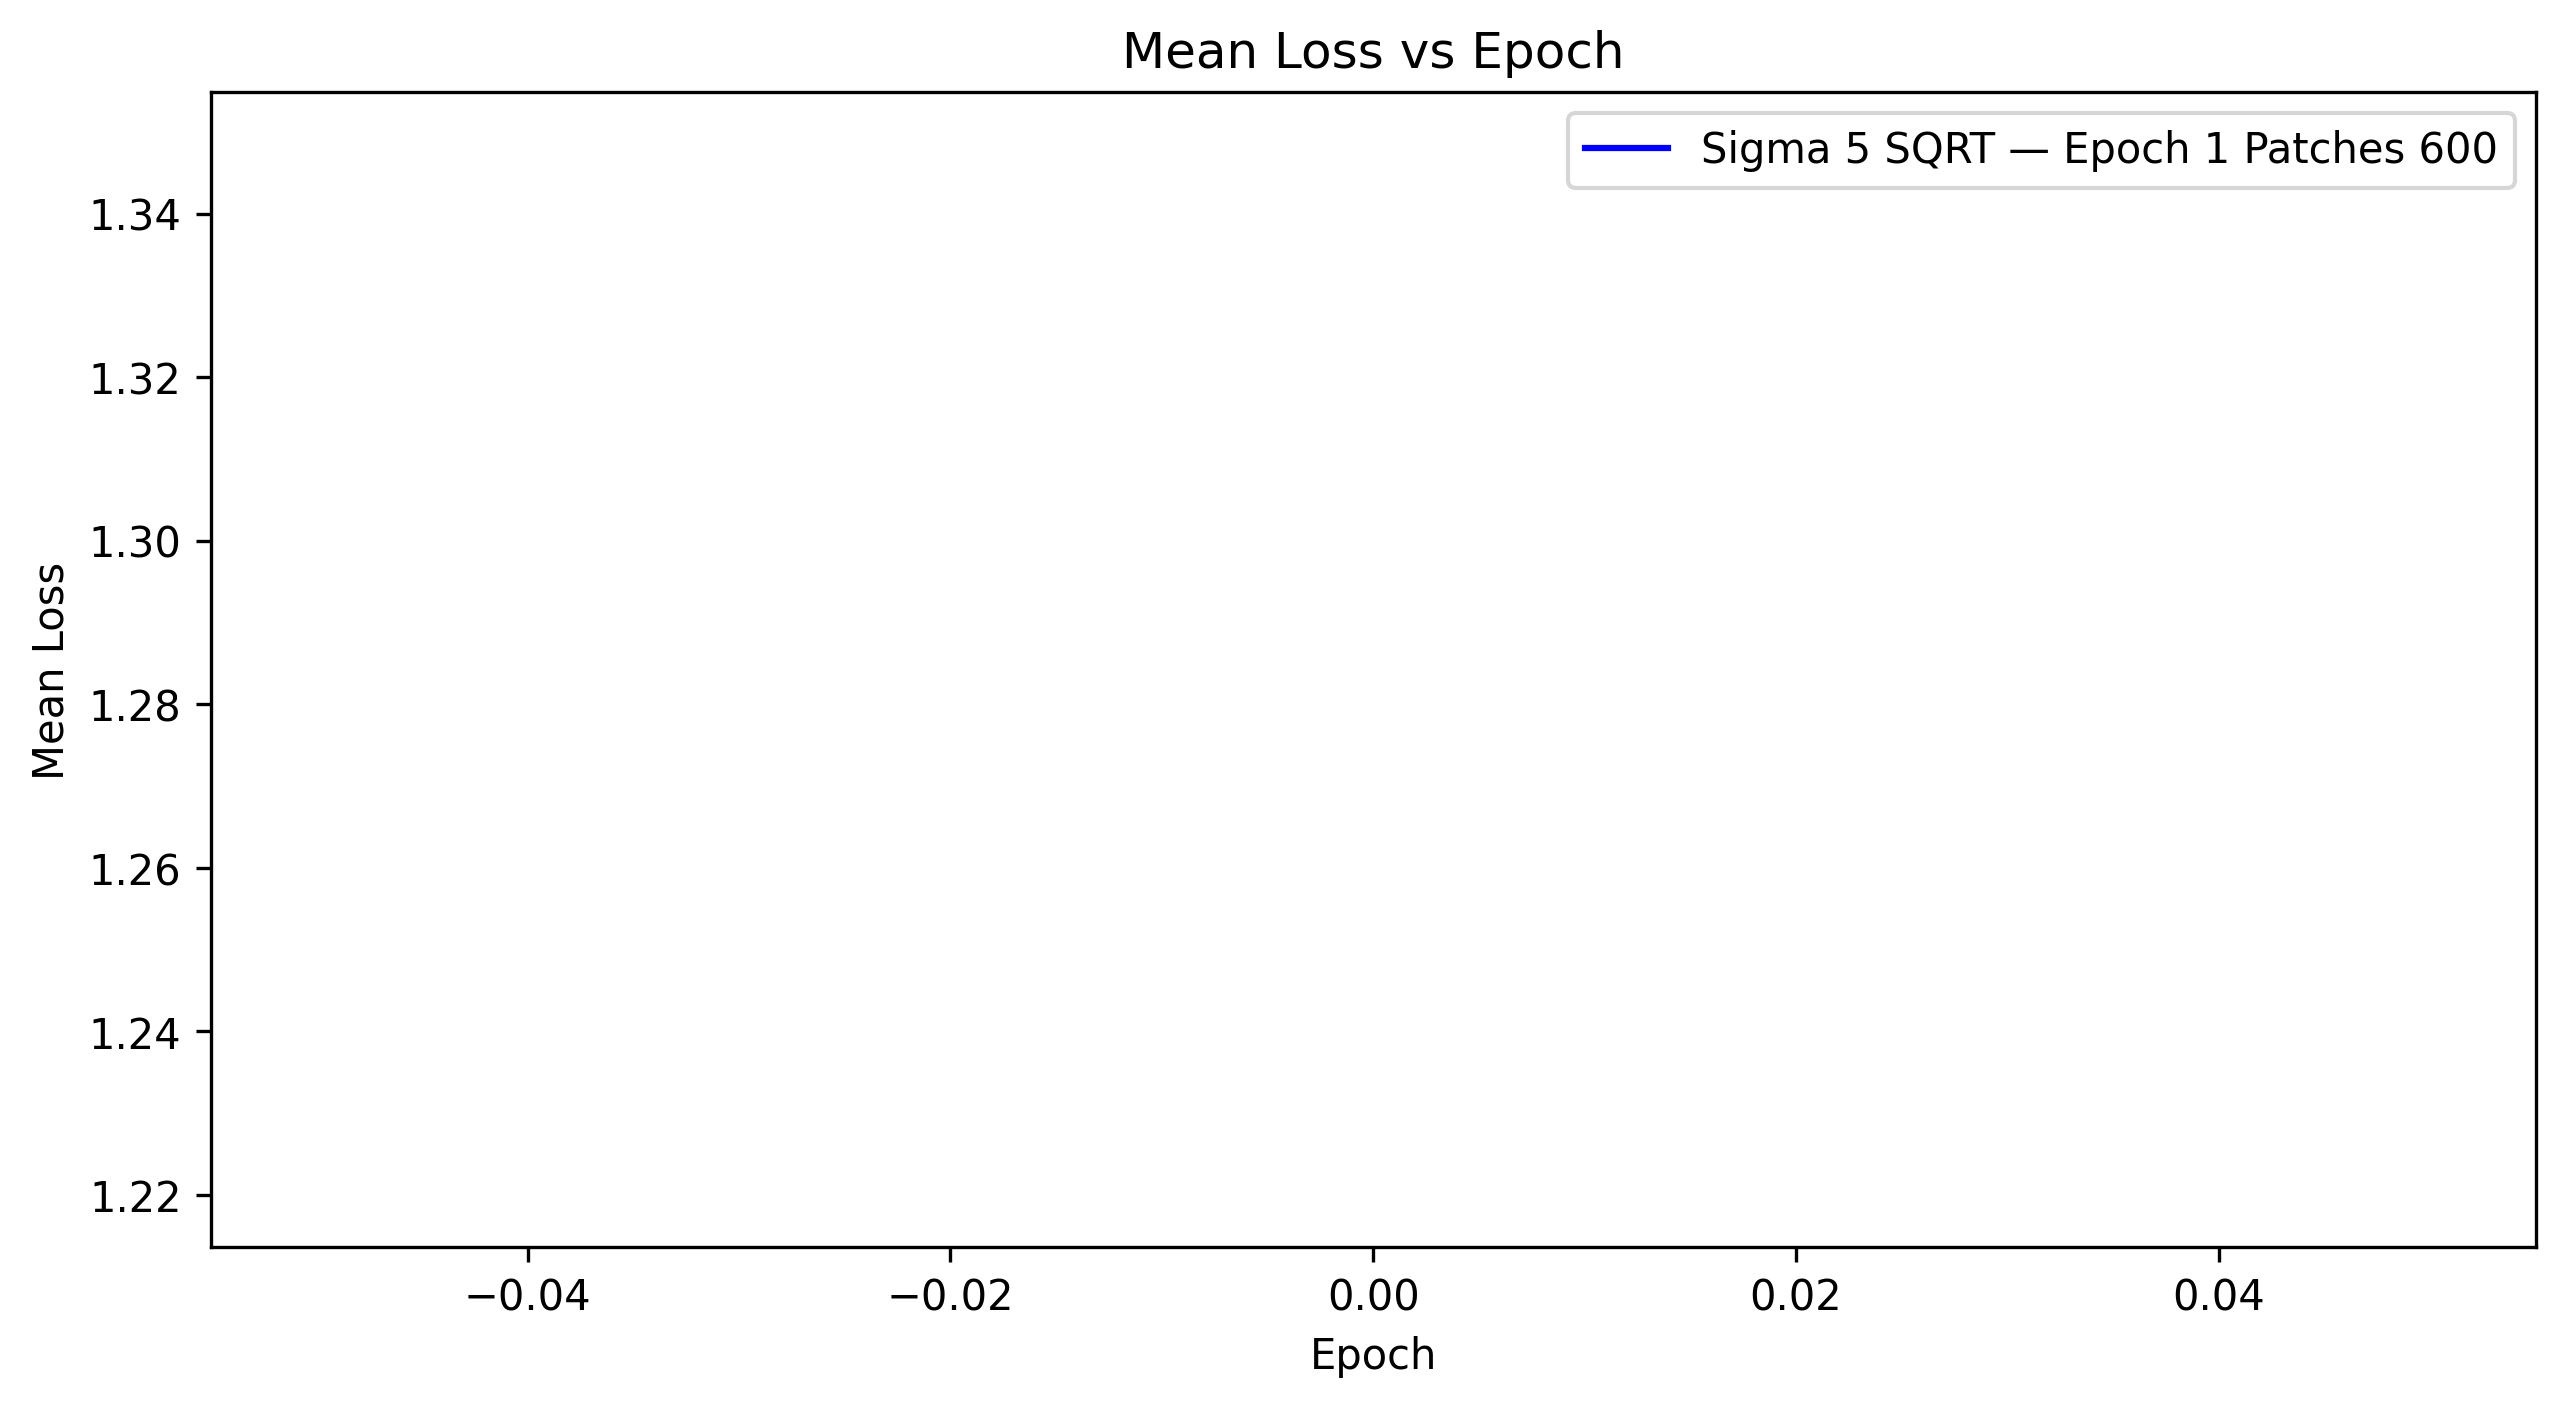

: 

In [73]:
from samrfi import RFITraining 

new_model = RFITraining(rfi_dataset, device='cuda', dir_path=dir_path)
new_model.train(num_epochs=1, batch_size=4)